## Let's Build a Quant Trading Strategy - Part 2

### Strategy types

In [497]:
# 1 Maker strategies => they are providing liquidity => adding liquidity to a market and aim to be compensated for it
# 2 Taker strategies => they taking away liquidity => market orders that consume liquidity => what we are going to focus on


# I've got another video — 'Introduction to Quantitative Trading' — that goes way deeper into taker and maker strategies. 
# If you want the full breakdown, definitely watch that one. Link's below."


# Key Questions for our taking strategy

# 1. Entry/Exit
# 2. Trade Sizing
# 3. Leverage
## the key goal is we want to create a strategy that maximises profits from the model's statistical edge

In [498]:
# Data and analysis libraries
import polars as pl                         # Fast dataframes for financial data
import numpy as np                          # Numerical computing library
from datetime import datetime, timedelta    # Date and time operations
import random


# Machine learning libraries  
import torch                                # PyTorch framework
import torch.nn as nn                       # Neural network modules
import torch.optim as optim                 # Optimization algorithms
import research                             # Model building and training utilities


# Visualization and 
import altair as alt                        # Interactive visualization library

# data sources
import binance                              # Binance market data utilities

In [499]:
import models
model = models.LinearModel(3)
# security alert 
model.load_state_dict(torch.load('model_weights.pth', weights_only=True))
model.eval()

LinearModel(
  (linear): Linear(in_features=3, out_features=1, bias=True)
)

### Model Parameters

In [500]:
research.print_model_params(model)

linear.weight:
[[-0.1185589  -0.09876697  0.05974434]]
linear.bias:
[0.00109685]


### What is mean reversion

In [501]:
series = [-0.014000, 0.011399, -0.012212, 0.01997, -0.01442, 0.01227]
mu = np.mean(series)
mean_reversion_df = pl.DataFrame({'log_return': series, 'mean': mu})
mean_reversion_df

log_return,mean
f64,f64
-0.014,0.000501
0.011399,0.000501
-0.012212,0.000501
0.01997,0.000501
-0.01442,0.000501
0.01227,0.000501


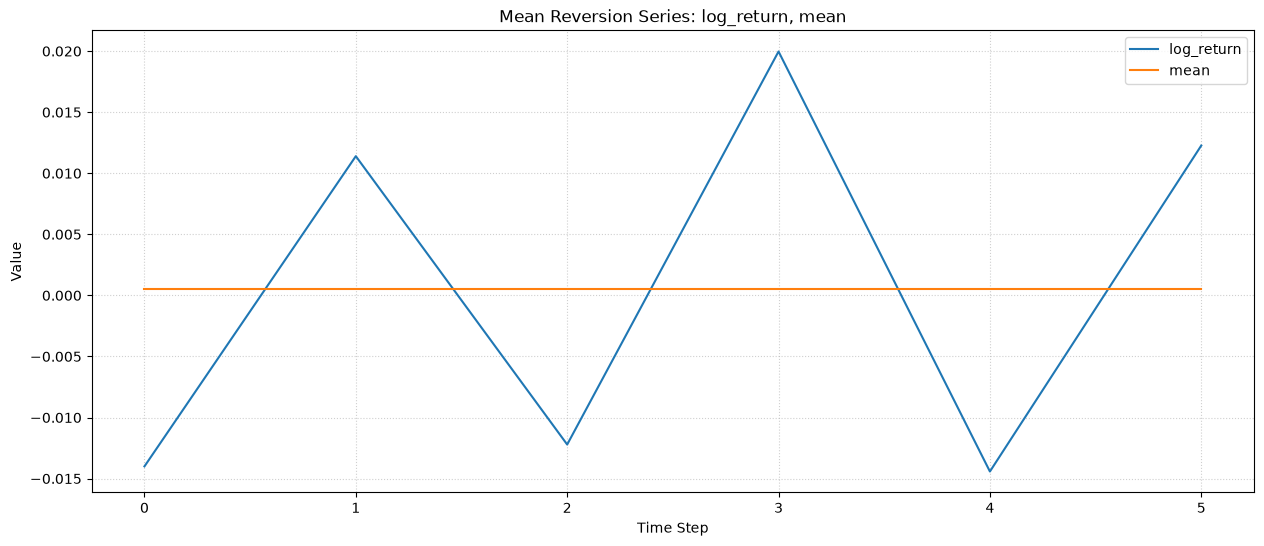

In [502]:
research.plot_multiple_lines(mean_reversion_df, ['log_return','mean'], 'Mean Reversion')

### Interpretability - Lineal Model

In [503]:
def linear_model(x):
    w, b = -0.09911217, 0.00059838
    return w * x + b

linear_model(-0.015) 

0.00208506255

In [504]:
linear_model(0.035) 

-0.0028705459500000005

In [505]:
linear_model(0.00000035) 

0.0005983453107405001

In [506]:
linear_model(0) 

0.00059838

### Interpretability - Non Linear Model

In [507]:
def nn_model(x):
    x = torch.tensor([x])
    W = torch.tensor([0.08035, -0.01478, -0.03523,  0.06777,  0.03789,  0.0013991, -0.13303,  0.8045])
    b = torch.tensor([0.16421])
    return torch.tanh(torch.sum(x * W) + b)

nn_model(-0.015)

tensor([0.1509])

In [508]:
nn_model(0.02)

tensor([0.1785])

### Strategy Development

#### Load Time Series

In [509]:
from pathlib import Path

import polars as pl
from binance.client import Client

sym = "BTCUSDT"
time_interval = "12h"
csv_path = Path(f"{sym}_{time_interval}_ohlc.csv")

if not csv_path.exists():
    client = Client()
    klines = client.get_historical_klines(
        symbol=sym,
        interval=Client.KLINE_INTERVAL_12HOUR,
        start_str="29 Oct 2024 00:00:00",
        end_str="09 Oct 2025 23:59:59",
    )

    if not klines:
        raise RuntimeError(f"Binance no devolvio datos para {sym}.")

    kline_columns = [
        "open_time",
        "open",
        "high",
        "low",
        "close",
        "volume",
        "close_time",
        "quote_volume",
        "trade_count",
        "taker_buy_volume",
        "taker_buy_quote_volume",
        "ignore",
    ]

    ts = (
        pl.DataFrame(klines, schema=kline_columns, orient="row")
        .select(
            pl.col("open_time")
            .cast(pl.Datetime("ms"))
            .alias("datetime"),
            pl.col("open").cast(pl.Float64),
            pl.col("high").cast(pl.Float64),
            pl.col("low").cast(pl.Float64),
            pl.col("close").cast(pl.Float64),
            pl.col("volume").cast(pl.Float64),
        )
        .sort("datetime")
    )
    ts.write_csv(csv_path)
    print(f"Datos descargados y guardados en: {csv_path}")
else:
    ts = pl.read_csv(csv_path, try_parse_dates=True).sort("datetime")
    print(f"Datos cargados desde: {csv_path}")

ts

Datos cargados desde: BTCUSDT_12h_ohlc.csv


datetime,open,high,low,close,volume
datetime[μs],f64,f64,f64,f64,f64
2024-10-29 00:00:00,69962.21,71587.88,69760.0,71452.01,18985.23669
2024-10-29 12:00:00,71452.02,73620.12,70929.0,72736.42,31143.36925
2024-10-30 00:00:00,72736.41,72785.72,71926.82,71983.99,9868.85743
2024-10-30 12:00:00,71984.0,72961.0,71436.0,72344.74,17017.13313
2024-10-31 00:00:00,72344.75,72700.0,72030.08,72226.0,8385.60352
…,…,…,…,…,…
2025-10-07 12:00:00,124453.37,125126.0,120574.94,121332.95,14960.42401
2025-10-08 00:00:00,121332.96,123200.0,121066.14,122884.14,8486.36814
2025-10-08 12:00:00,122884.14,124197.25,121649.68,123306.0,8526.24986


### Add Target and Features

In [510]:
sym = 'BTCUSDT'
forecast_horizon = 1
ts = research.add_log_return_features(ts, 'close', forecast_horizon, max_no_lags=3)
ts

datetime,open,high,low,close,volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2024-10-29 00:00:00,69962.21,71587.88,69760.0,71452.01,18985.23669,null,null,null,null
2024-10-29 12:00:00,71452.02,73620.12,70929.0,72736.42,31143.36925,0.017816,null,null,null
2024-10-30 00:00:00,72736.41,72785.72,71926.82,71983.99,9868.85743,-0.010398,0.017816,null,null
2024-10-30 12:00:00,71984.0,72961.0,71436.0,72344.74,17017.13313,0.004999,-0.010398,0.017816,null
2024-10-31 00:00:00,72344.75,72700.0,72030.08,72226.0,8385.60352,-0.001643,0.004999,-0.010398,0.017816
…,…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124453.37,125126.0,120574.94,121332.95,14960.42401,-0.025393,-0.001647,0.003564,0.005916
2025-10-08 00:00:00,121332.96,123200.0,121066.14,122884.14,8486.36814,0.012704,-0.025393,-0.001647,0.003564
2025-10-08 12:00:00,122884.14,124197.25,121649.68,123306.0,8526.24986,0.003427,0.012704,-0.025393,-0.001647


In [511]:
test_size = 0.25
_, trades = research.timeseries_split(ts, test_size)
trades

datetime,open,high,low,close,volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-07-15 12:00:00,117113.98,118490.71,115736.92,117758.09,16303.91044,0.005485,-0.02302,-0.013477,0.019793
2025-07-16 00:00:00,117758.08,119310.75,117017.29,118769.06,6372.811,0.008548,0.005485,-0.02302,-0.013477
2025-07-16 12:00:00,118769.06,120063.84,118181.14,118630.43,10667.09751,-0.001168,0.008548,0.005485,-0.02302
2025-07-17 00:00:00,118630.44,119192.0,117683.53,117995.0,6356.57902,-0.005371,-0.001168,0.008548,0.005485
2025-07-17 12:00:00,117995.0,120998.71,117453.57,119177.56,9371.99749,0.009972,-0.005371,-0.001168,0.008548
…,…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124453.37,125126.0,120574.94,121332.95,14960.42401,-0.025393,-0.001647,0.003564,0.005916
2025-10-08 00:00:00,121332.96,123200.0,121066.14,122884.14,8486.36814,0.012704,-0.025393,-0.001647,0.003564
2025-10-08 12:00:00,122884.14,124197.25,121649.68,123306.0,8526.24986,0.003427,0.012704,-0.025393,-0.001647


## Strategy decision #1: Entry/Exit Signal

In [512]:
# q1: when do we get in? entry signal
# q2: when do we get out? exit signal

In [513]:
# 1. Time Based 
# 2. Predicate Based 

In [514]:
# predicate example => we only want to trade if our y_hat is above or below a certain threshold

In [515]:
# time based => each row represents a roundtrip trade. trade to open position at start of interval, trade to close the position at end of interval. each row = 2 trades. 

## Add Model's Predictions

In [516]:
target = 'close_log_return'
features = [f'{target}_lag_1',f'{target}_lag_2',f'{target}_lag_3']
trades = research.add_model_predictions(trades, model, features)
trades

datetime,open,high,low,close,volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f32
2025-07-15 12:00:00,117113.98,118490.71,115736.92,117758.09,16303.91044,0.005485,-0.02302,-0.013477,0.019793,0.00634
2025-07-16 00:00:00,117758.08,119310.75,117017.29,118769.06,6372.811,0.008548,0.005485,-0.02302,-0.013477,0.001915
2025-07-16 12:00:00,118769.06,120063.84,118181.14,118630.43,10667.09751,-0.001168,0.008548,0.005485,-0.02302,-0.001834
2025-07-17 00:00:00,118630.44,119192.0,117683.53,117995.0,6356.57902,-0.005371,-0.001168,0.008548,0.005485,0.000719
2025-07-17 12:00:00,117995.0,120998.71,117453.57,119177.56,9371.99749,0.009972,-0.005371,-0.001168,0.008548,0.00236
…,…,…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124453.37,125126.0,120574.94,121332.95,14960.42401,-0.025393,-0.001647,0.003564,0.005916,0.001294
2025-10-08 00:00:00,121332.96,123200.0,121066.14,122884.14,8486.36814,0.012704,-0.025393,-0.001647,0.003564,0.004483
2025-10-08 12:00:00,122884.14,124197.25,121649.68,123306.0,8526.24986,0.003427,0.012704,-0.025393,-0.001647,0.002


### Add Directional Signal

In [517]:
trades = trades.with_columns(pl.col('y_hat').sign().alias('dir_signal'))
trades

datetime,open,high,low,close,volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f32,f32
2025-07-15 12:00:00,117113.98,118490.71,115736.92,117758.09,16303.91044,0.005485,-0.02302,-0.013477,0.019793,0.00634,1.0
2025-07-16 00:00:00,117758.08,119310.75,117017.29,118769.06,6372.811,0.008548,0.005485,-0.02302,-0.013477,0.001915,1.0
2025-07-16 12:00:00,118769.06,120063.84,118181.14,118630.43,10667.09751,-0.001168,0.008548,0.005485,-0.02302,-0.001834,-1.0
2025-07-17 00:00:00,118630.44,119192.0,117683.53,117995.0,6356.57902,-0.005371,-0.001168,0.008548,0.005485,0.000719,1.0
2025-07-17 12:00:00,117995.0,120998.71,117453.57,119177.56,9371.99749,0.009972,-0.005371,-0.001168,0.008548,0.00236,1.0
…,…,…,…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124453.37,125126.0,120574.94,121332.95,14960.42401,-0.025393,-0.001647,0.003564,0.005916,0.001294,1.0
2025-10-08 00:00:00,121332.96,123200.0,121066.14,122884.14,8486.36814,0.012704,-0.025393,-0.001647,0.003564,0.004483,1.0
2025-10-08 12:00:00,122884.14,124197.25,121649.68,123306.0,8526.24986,0.003427,0.012704,-0.025393,-0.001647,0.002,1.0


### Calculate Trade Log Return

In [518]:
trades = trades.with_columns((pl.col('close_log_return')*pl.col('dir_signal')).alias('trade_log_return'))
trades

datetime,open,high,low,close,volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64
2025-07-15 12:00:00,117113.98,118490.71,115736.92,117758.09,16303.91044,0.005485,-0.02302,-0.013477,0.019793,0.00634,1.0,0.005485
2025-07-16 00:00:00,117758.08,119310.75,117017.29,118769.06,6372.811,0.008548,0.005485,-0.02302,-0.013477,0.001915,1.0,0.008548
2025-07-16 12:00:00,118769.06,120063.84,118181.14,118630.43,10667.09751,-0.001168,0.008548,0.005485,-0.02302,-0.001834,-1.0,0.001168
2025-07-17 00:00:00,118630.44,119192.0,117683.53,117995.0,6356.57902,-0.005371,-0.001168,0.008548,0.005485,0.000719,1.0,-0.005371
2025-07-17 12:00:00,117995.0,120998.71,117453.57,119177.56,9371.99749,0.009972,-0.005371,-0.001168,0.008548,0.00236,1.0,0.009972
…,…,…,…,…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124453.37,125126.0,120574.94,121332.95,14960.42401,-0.025393,-0.001647,0.003564,0.005916,0.001294,1.0,-0.025393
2025-10-08 00:00:00,121332.96,123200.0,121066.14,122884.14,8486.36814,0.012704,-0.025393,-0.001647,0.003564,0.004483,1.0,0.012704
2025-10-08 12:00:00,122884.14,124197.25,121649.68,123306.0,8526.24986,0.003427,0.012704,-0.025393,-0.001647,0.002,1.0,0.003427


### Calculate Cumulative Trade Log Return

In [519]:
trades = trades.with_columns(
    pl.col('trade_log_return').cum_sum().alias('cum_trade_log_return')
    )
trades

datetime,open,high,low,close,volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return,cum_trade_log_return
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64,f64
2025-07-15 12:00:00,117113.98,118490.71,115736.92,117758.09,16303.91044,0.005485,-0.02302,-0.013477,0.019793,0.00634,1.0,0.005485,0.005485
2025-07-16 00:00:00,117758.08,119310.75,117017.29,118769.06,6372.811,0.008548,0.005485,-0.02302,-0.013477,0.001915,1.0,0.008548,0.014033
2025-07-16 12:00:00,118769.06,120063.84,118181.14,118630.43,10667.09751,-0.001168,0.008548,0.005485,-0.02302,-0.001834,-1.0,0.001168,0.015201
2025-07-17 00:00:00,118630.44,119192.0,117683.53,117995.0,6356.57902,-0.005371,-0.001168,0.008548,0.005485,0.000719,1.0,-0.005371,0.00983
2025-07-17 12:00:00,117995.0,120998.71,117453.57,119177.56,9371.99749,0.009972,-0.005371,-0.001168,0.008548,0.00236,1.0,0.009972,0.019803
…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124453.37,125126.0,120574.94,121332.95,14960.42401,-0.025393,-0.001647,0.003564,0.005916,0.001294,1.0,-0.025393,0.155056
2025-10-08 00:00:00,121332.96,123200.0,121066.14,122884.14,8486.36814,0.012704,-0.025393,-0.001647,0.003564,0.004483,1.0,0.012704,0.167759
2025-10-08 12:00:00,122884.14,124197.25,121649.68,123306.0,8526.24986,0.003427,0.012704,-0.025393,-0.001647,0.002,1.0,0.003427,0.171186


### Display Equity Curve (Log Space)

In [520]:
research.plot_column(trades, 'cum_trade_log_return')

alt.Chart(...)

### Key Strategy Decision #2: Trade Sizing

In [521]:
# 1. Constant Trade Size
# 2. Compounding Trade Size

In [522]:
capital = 100
ratio = 1.0 # you could experiment with different ratios like kelly criterion
trade_value = ratio * capital

# entry trade value and exit trade value
trades = trades.with_columns(
    pl.lit(trade_value).alias('entry_trade_value'),
    (trade_value * pl.col('trade_log_return').exp()).alias('exit_trade_value'),
    (trade_value / pl.col('open')).alias('trade_qty'),
).with_columns(
    (pl.col('trade_qty') * pl.col('dir_signal')).alias('signed_trade_qty'),
)

trades.select('datetime','open','close', 'trade_log_return','y_hat','entry_trade_value','exit_trade_value', 'signed_trade_qty')

datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty
datetime[μs],f64,f64,f64,f32,f64,f64,f64
2025-07-15 12:00:00,117113.98,117758.09,0.005485,0.00634,100.0,100.549986,0.000854
2025-07-16 00:00:00,117758.08,118769.06,0.008548,0.001915,100.0,100.858514,0.000849
2025-07-16 12:00:00,118769.06,118630.43,0.001168,-0.001834,100.0,100.116859,-0.000842
2025-07-17 00:00:00,118630.44,117995.0,-0.005371,0.000719,100.0,99.464362,0.000843
2025-07-17 12:00:00,117995.0,119177.56,0.009972,0.00236,100.0,101.002212,0.000847
…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124453.37,121332.95,-0.025393,0.001294,100.0,97.492692,0.000804
2025-10-08 00:00:00,121332.96,122884.14,0.012704,0.004483,100.0,101.278457,0.000824
2025-10-08 12:00:00,122884.14,123306.0,0.003427,0.002,100.0,100.343299,0.000814


### Add Trade Gross PnL

In [523]:
trades = trades.with_columns(
    (pl.col('exit_trade_value') - pl.col('entry_trade_value')).alias('trade_gross_pnl')
    )
trades.select('datetime','open','close', 'trade_log_return','y_hat','entry_trade_value','exit_trade_value', 'signed_trade_qty', )

datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty
datetime[μs],f64,f64,f64,f32,f64,f64,f64
2025-07-15 12:00:00,117113.98,117758.09,0.005485,0.00634,100.0,100.549986,0.000854
2025-07-16 00:00:00,117758.08,118769.06,0.008548,0.001915,100.0,100.858514,0.000849
2025-07-16 12:00:00,118769.06,118630.43,0.001168,-0.001834,100.0,100.116859,-0.000842
2025-07-17 00:00:00,118630.44,117995.0,-0.005371,0.000719,100.0,99.464362,0.000843
2025-07-17 12:00:00,117995.0,119177.56,0.009972,0.00236,100.0,101.002212,0.000847
…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124453.37,121332.95,-0.025393,0.001294,100.0,97.492692,0.000804
2025-10-08 00:00:00,121332.96,122884.14,0.012704,0.004483,100.0,101.278457,0.000824
2025-10-08 12:00:00,122884.14,123306.0,0.003427,0.002,100.0,100.343299,0.000814


### Add Transaction Fee

In [524]:
maker_fee = 0.0001  # 0.08%
taker_fee = 0.0003  # 0.10%

trades = trades.with_columns(
    (pl.col('entry_trade_value') * taker_fee + pl.col('exit_trade_value') * taker_fee).alias('taker_fee'),
    (pl.col('entry_trade_value') * maker_fee + pl.col('exit_trade_value') * maker_fee).alias('maker_fee')
)

trades.select('datetime','open','close', 'trade_log_return','y_hat','entry_trade_value','exit_trade_value', 'signed_trade_qty', 'trade_gross_pnl','maker_fee','taker_fee')

datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty,trade_gross_pnl,maker_fee,taker_fee
datetime[μs],f64,f64,f64,f32,f64,f64,f64,f64,f64,f64
2025-07-15 12:00:00,117113.98,117758.09,0.005485,0.00634,100.0,100.549986,0.000854,0.549986,0.020055,0.060165
2025-07-16 00:00:00,117758.08,118769.06,0.008548,0.001915,100.0,100.858514,0.000849,0.858514,0.020086,0.060258
2025-07-16 12:00:00,118769.06,118630.43,0.001168,-0.001834,100.0,100.116859,-0.000842,0.116859,0.020012,0.060035
2025-07-17 00:00:00,118630.44,117995.0,-0.005371,0.000719,100.0,99.464362,0.000843,-0.535638,0.019946,0.059839
2025-07-17 12:00:00,117995.0,119177.56,0.009972,0.00236,100.0,101.002212,0.000847,1.002212,0.0201,0.060301
…,…,…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124453.37,121332.95,-0.025393,0.001294,100.0,97.492692,0.000804,-2.507308,0.019749,0.059248
2025-10-08 00:00:00,121332.96,122884.14,0.012704,0.004483,100.0,101.278457,0.000824,1.278457,0.020128,0.060384
2025-10-08 12:00:00,122884.14,123306.0,0.003427,0.002,100.0,100.343299,0.000814,0.343299,0.020034,0.060103


### Calculate Trade Net PnL

In [525]:
trades = trades.with_columns(
    (pl.col('trade_gross_pnl')-pl.col('taker_fee')).alias('trade_net_taker_pnl'),
    (pl.col('trade_gross_pnl')-pl.col('maker_fee')).alias('trade_net_maker_pnl'),
)

trades.select('datetime','open','close', 'trade_log_return','y_hat','entry_trade_value','exit_trade_value', 'signed_trade_qty', 'trade_gross_pnl','trade_net_taker_pnl','trade_net_maker_pnl')

datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty,trade_gross_pnl,trade_net_taker_pnl,trade_net_maker_pnl
datetime[μs],f64,f64,f64,f32,f64,f64,f64,f64,f64,f64
2025-07-15 12:00:00,117113.98,117758.09,0.005485,0.00634,100.0,100.549986,0.000854,0.549986,0.489821,0.529931
2025-07-16 00:00:00,117758.08,118769.06,0.008548,0.001915,100.0,100.858514,0.000849,0.858514,0.798257,0.838428
2025-07-16 12:00:00,118769.06,118630.43,0.001168,-0.001834,100.0,100.116859,-0.000842,0.116859,0.056824,0.096847
2025-07-17 00:00:00,118630.44,117995.0,-0.005371,0.000719,100.0,99.464362,0.000843,-0.535638,-0.595478,-0.555585
2025-07-17 12:00:00,117995.0,119177.56,0.009972,0.00236,100.0,101.002212,0.000847,1.002212,0.941911,0.982112
…,…,…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124453.37,121332.95,-0.025393,0.001294,100.0,97.492692,0.000804,-2.507308,-2.566556,-2.527058
2025-10-08 00:00:00,121332.96,122884.14,0.012704,0.004483,100.0,101.278457,0.000824,1.278457,1.218074,1.258329
2025-10-08 12:00:00,122884.14,123306.0,0.003427,0.002,100.0,100.343299,0.000814,0.343299,0.283196,0.323265


### Display Equity Curves for Constant Sizing

In [526]:
def equity_curve(capital, col_name, suffix):
    return (capital + (pl.col(col_name).cum_sum())).alias(f'equity_curve_{suffix}')

trades = trades.with_columns(
    equity_curve(capital, 'trade_net_taker_pnl', 'taker'),
    equity_curve(capital, 'trade_net_maker_pnl', 'maker'),
    equity_curve(capital, 'trade_gross_pnl', 'gross'),
)
trades.select('datetime','equity_curve_gross','equity_curve_taker','equity_curve_maker')

datetime,equity_curve_gross,equity_curve_taker,equity_curve_maker
datetime[μs],f64,f64,f64
2025-07-15 12:00:00,100.549986,100.489821,100.529931
2025-07-16 00:00:00,101.4085,101.288077,101.368359
2025-07-16 12:00:00,101.525359,101.344901,101.465206
2025-07-17 00:00:00,100.98972,100.749423,100.909621
2025-07-17 12:00:00,101.991932,101.691335,101.891733
…,…,…,…
2025-10-07 12:00:00,116.375892,106.230979,112.994254
2025-10-08 00:00:00,117.654349,107.449053,114.252584
2025-10-08 12:00:00,117.997648,107.732249,114.575849


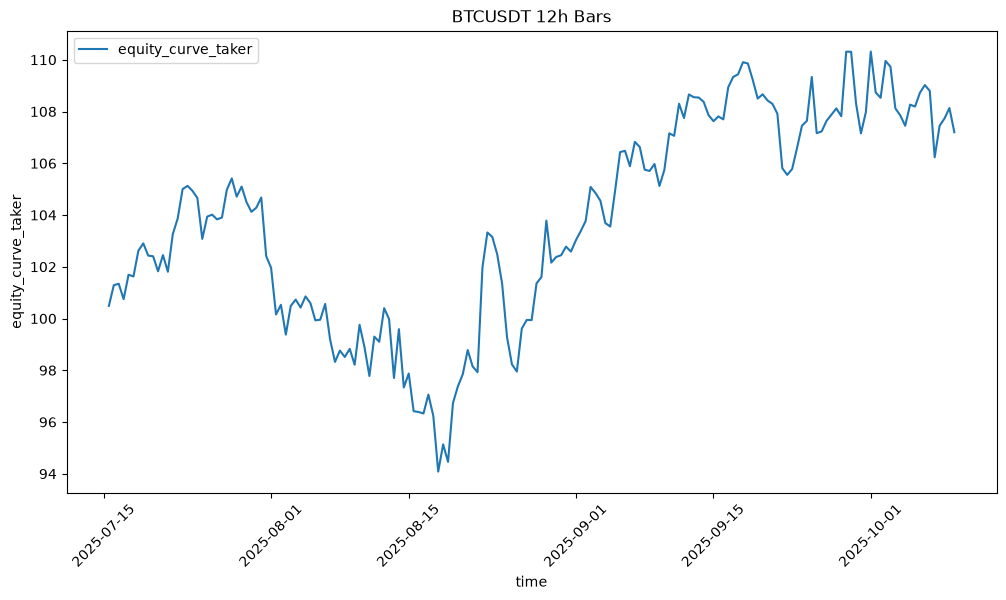

In [527]:
research.plot_static_timeseries(trades, sym, 'equity_curve_taker', time_interval)

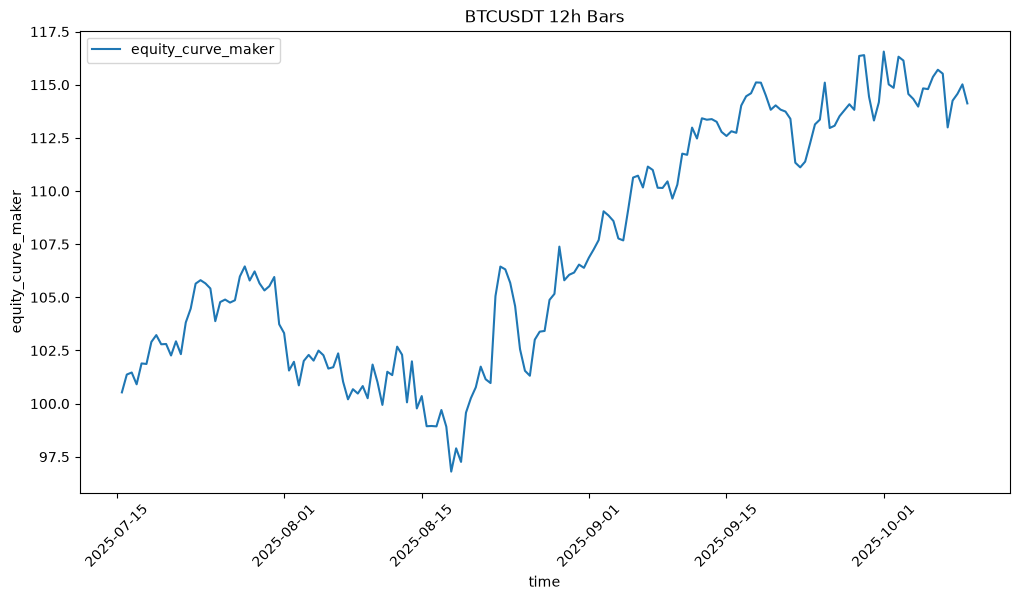

In [528]:
research.plot_static_timeseries(trades, sym, 'equity_curve_maker', time_interval)

### Calculate Total Net Return using Constant Sizing

In [529]:
constant_sizing_net_return = trades['equity_curve_taker'][-1] / capital - 1
constant_sizing_net_return

0.0719950828463527

### Experiment with compounding trade sizes

In [530]:
# 2 => 102 (100 + 2)
# 1 => 103 (100 + 2 + 1)
# -1 => 102 (100 + 2 + 1 - 1)

In [531]:
log_return_1 = 0.005439
pnl1 = capital * np.exp(log_return_1)
pnl1

np.float64(100.54538182137402)

In [532]:
log_return_2 = 0.008597
pnl2 = pnl1 * np.exp(log_return_2)
pnl2

np.float64(101.41349671401576)

In [533]:
log_return_3 = 0.001385
pnl3 = pnl2 * np.exp(log_return_3)
pnl3

np.float64(101.55405171883751)

In [534]:
((capital * np.exp(log_return_1)) * np.exp(log_return_2)) * np.exp(log_return_3)

np.float64(101.55405171883751)

### Time Additivity

In [535]:
capital * np.exp(log_return_1 + log_return_2 + log_return_3)

np.float64(101.55405171883751)

### Add Compounding Trade Sizes

In [536]:
net_trade_multiplier = (
    pl.col('trade_log_return').exp() * (1 - taker_fee) - taker_fee
)
net_exit_value = capital * net_trade_multiplier.cum_prod()

trades = trades.with_columns(
    net_exit_value.shift().fill_null(capital).alias('entry_trade_value')
).with_columns(
    (pl.col('entry_trade_value') * pl.col('trade_log_return').exp()).alias('exit_trade_value')
).with_columns(
    (pl.col('entry_trade_value') / pl.col('open') * pl.col('dir_signal')).alias('signed_trade_qty'),
    (pl.col('exit_trade_value') - pl.col('entry_trade_value')).alias('trade_gross_pnl'),
)
trades.select('datetime','open','close','trade_log_return','entry_trade_value','exit_trade_value','signed_trade_qty','trade_gross_pnl')

datetime,open,close,trade_log_return,entry_trade_value,exit_trade_value,signed_trade_qty,trade_gross_pnl
datetime[μs],f64,f64,f64,f64,f64,f64,f64
2025-07-15 12:00:00,117113.98,117758.09,0.005485,100.0,100.549986,0.000854,0.549986
2025-07-16 00:00:00,117758.08,118769.06,0.008548,100.489821,101.35254,0.000853,0.862719
2025-07-16 12:00:00,118769.06,118630.43,0.001168,101.291987,101.410356,-0.000853,0.118369
2025-07-17 00:00:00,118630.44,117995.0,-0.005371,101.349545,100.806678,0.000854,-0.542867
2025-07-17 12:00:00,117995.0,119177.56,0.009972,100.746031,101.75572,0.000854,1.009689
…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124453.37,121332.95,-0.025393,108.292954,105.577716,0.00087,-2.715238
2025-10-08 00:00:00,121332.96,122884.14,0.012704,105.513554,106.8625,0.00087,1.348946
2025-10-08 12:00:00,122884.14,123306.0,0.003427,106.798787,107.165427,0.000869,0.366639


### Add Transaction Fees

In [537]:
trades = research.add_tx_fees(trades, maker_fee, taker_fee)
trades.select('datetime','entry_trade_value','exit_trade_value','tx_fee_maker','tx_fee_taker')

datetime,entry_trade_value,exit_trade_value,tx_fee_maker,tx_fee_taker
datetime[μs],f64,f64,f64,f64
2025-07-15 12:00:00,100.0,100.549986,0.020055,0.060165
2025-07-16 00:00:00,100.489821,101.35254,0.020184,0.060553
2025-07-16 12:00:00,101.291987,101.410356,0.02027,0.060811
2025-07-17 00:00:00,101.349545,100.806678,0.020216,0.060647
2025-07-17 12:00:00,100.746031,101.75572,0.02025,0.060751
…,…,…,…,…
2025-10-07 12:00:00,108.292954,105.577716,0.021387,0.064161
2025-10-08 00:00:00,105.513554,106.8625,0.021238,0.063713
2025-10-08 12:00:00,106.798787,107.165427,0.021396,0.064189


### Add Trade Net PnL

In [538]:
trades = trades.with_columns(
    (pl.col('entry_trade_value') + pl.col('trade_gross_pnl')).alias('exit_trade_value'),
    (pl.col('entry_trade_value') + pl.col('trade_gross_pnl') - pl.col('tx_fee_taker')).alias('exit_trade_value_net'),
    pl.col('trade_gross_pnl').alias('trade_pnl_without_fees'),
    (pl.col('trade_gross_pnl') - pl.col('tx_fee_taker')).alias('trade_net_taker_pnl')
)
trades.select(
    'datetime','open','close','close_log_return','y_hat',
    'entry_trade_value','exit_trade_value','tx_fee_taker',
    'exit_trade_value_net','trade_pnl_without_fees','trade_net_taker_pnl'
)

datetime,open,close,close_log_return,y_hat,entry_trade_value,exit_trade_value,tx_fee_taker,exit_trade_value_net,trade_pnl_without_fees,trade_net_taker_pnl
datetime[μs],f64,f64,f64,f32,f64,f64,f64,f64,f64,f64
2025-07-15 12:00:00,117113.98,117758.09,0.005485,0.00634,100.0,100.549986,0.060165,100.489821,0.549986,0.489821
2025-07-16 00:00:00,117758.08,118769.06,0.008548,0.001915,100.489821,101.35254,0.060553,101.291987,0.862719,0.802167
2025-07-16 12:00:00,118769.06,118630.43,-0.001168,-0.001834,101.291987,101.410356,0.060811,101.349545,0.118369,0.057558
2025-07-17 00:00:00,118630.44,117995.0,-0.005371,0.000719,101.349545,100.806678,0.060647,100.746031,-0.542867,-0.603514
2025-07-17 12:00:00,117995.0,119177.56,0.009972,0.00236,100.746031,101.75572,0.060751,101.69497,1.009689,0.948938
…,…,…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124453.37,121332.95,-0.025393,0.001294,108.292954,105.577716,0.064161,105.513554,-2.715238,-2.779399
2025-10-08 00:00:00,121332.96,122884.14,0.012704,0.004483,105.513554,106.8625,0.063713,106.798787,1.348946,1.285233
2025-10-08 12:00:00,122884.14,123306.0,0.003427,0.002,106.798787,107.165427,0.064189,107.101237,0.366639,0.30245


### Equity Curve Compund Taker Strat

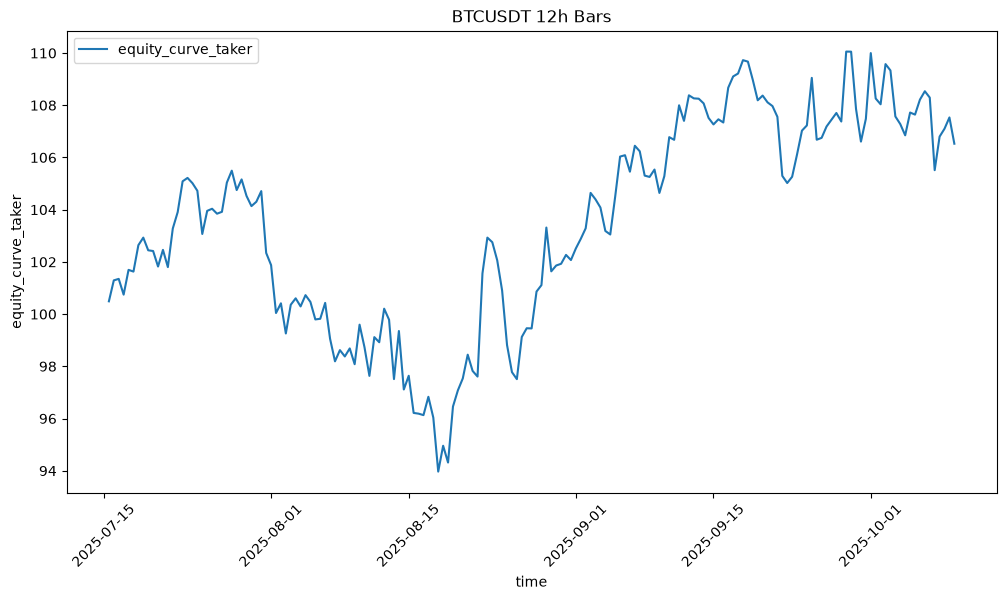

In [539]:
trades = research.add_equity_curve(trades, capital, 'trade_net_taker_pnl', 'taker')
research.plot_static_timeseries(trades, sym, 'equity_curve_taker', time_interval)

### Calculate Total Net Return for Compounding Trade Sizing

In [540]:
compound_total_net_return = trades['equity_curve_taker'][-1] / capital - 1
compound_total_net_return

0.06526626702498173

In [541]:
constant_sizing_net_return

0.0719950828463527

In [542]:
np.round(compound_total_net_return - constant_sizing_net_return, 2)

np.float64(-0.01)

### Key Strategy Decision #3: Leverage

In [543]:
leverage = 4

leverage * capital 

400

In [544]:
trades = research.add_compounding_trades(trades, capital, leverage, maker_fee, taker_fee)
trades

datetime,open,high,low,close,volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return,cum_trade_log_return,entry_trade_value,exit_trade_value,trade_qty,signed_trade_qty,trade_gross_pnl,taker_fee,maker_fee,trade_net_taker_pnl,trade_net_maker_pnl,equity_curve_taker,equity_curve_maker,equity_curve_gross,tx_fee_maker,tx_fee_taker,exit_trade_value_net,trade_pnl_without_fees
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-07-15 12:00:00,117113.98,118490.71,115736.92,117758.09,16303.91044,0.005485,-0.02302,-0.013477,0.019793,0.00634,1.0,0.005485,0.005485,400.0,402.199942,0.000854,0.003415,2.199942,0.060165,0.020055,1.959282,2.119722,101.959282,102.119722,102.199942,0.08022,0.24066,100.489821,0.549986
2025-07-16 00:00:00,117758.08,119310.75,117017.29,118769.06,6372.811,0.008548,0.005485,-0.02302,-0.013477,0.001915,1.0,0.008548,0.014033,402.199942,405.652886,0.000849,0.003415,3.452944,0.060258,0.020086,3.210588,3.372159,105.16987,105.491881,105.652886,0.080785,0.242356,101.291987,0.862719
2025-07-16 12:00:00,118769.06,120063.84,118181.14,118630.43,10667.09751,-0.001168,0.008548,0.005485,-0.02302,-0.001834,-1.0,0.001168,0.015201,405.652886,406.126927,0.000842,-0.003415,0.474041,0.060035,0.020012,0.230507,0.392863,105.400377,105.884744,106.126927,0.081178,0.243534,101.349545,0.118369
2025-07-17 00:00:00,118630.44,119192.0,117683.53,117995.0,6356.57902,-0.005371,-0.001168,0.008548,0.005485,0.000719,1.0,-0.005371,0.00983,406.126927,403.951556,0.000843,0.003423,-2.175371,0.059839,0.019946,-2.418395,-2.256379,102.981982,103.628365,103.951556,0.081008,0.243024,100.746031,-0.542867
2025-07-17 12:00:00,117995.0,120998.71,117453.57,119177.56,9371.99749,0.009972,-0.005371,-0.001168,0.008548,0.00236,1.0,0.009972,0.019803,403.951556,408.000006,0.000847,0.003423,4.048451,0.060301,0.0201,3.804865,3.967256,106.786848,107.59562,108.000006,0.081195,0.243585,101.69497,1.009689
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124453.37,125126.0,120574.94,121332.95,14960.42401,-0.025393,-0.001647,0.003564,0.005916,0.001294,1.0,-0.025393,0.155056,479.101774,467.089215,0.000804,0.00385,-12.012559,0.059248,0.019749,-12.296416,-12.107178,122.92048,152.366303,167.089215,0.094619,0.283857,105.513554,-2.715238
2025-10-08 00:00:00,121332.96,123200.0,121066.14,122884.14,8486.36814,0.012704,-0.025393,-0.001647,0.003564,0.004483,1.0,0.012704,0.167759,467.089215,473.060752,0.000824,0.00385,5.971536,0.060384,0.020128,5.689491,5.877521,128.609971,158.243825,173.060752,0.094015,0.282045,106.798787,1.348946
2025-10-08 12:00:00,122884.14,124197.25,121649.68,123306.0,8526.24986,0.003427,0.012704,-0.025393,-0.001647,0.002,1.0,0.003427,0.171186,473.060752,474.684764,0.000814,0.00385,1.624013,0.060103,0.020034,1.339689,1.529238,129.94966,159.773063,174.684764,0.094775,0.284324,107.101237,0.366639


### Calculate Total Net Return

In [545]:
trades['equity_curve_taker'][-1] / capital - 1

0.27400250089564615

### 8x Leverage

In [546]:
trades = research.add_compounding_trades(trades, capital, 8, maker_fee, taker_fee)
trades

datetime,open,high,low,close,volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return,cum_trade_log_return,entry_trade_value,exit_trade_value,trade_qty,signed_trade_qty,trade_gross_pnl,taker_fee,maker_fee,trade_net_taker_pnl,trade_net_maker_pnl,equity_curve_taker,equity_curve_maker,equity_curve_gross,tx_fee_maker,tx_fee_taker,exit_trade_value_net,trade_pnl_without_fees
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-07-15 12:00:00,117113.98,118490.71,115736.92,117758.09,16303.91044,0.005485,-0.02302,-0.013477,0.019793,0.00634,1.0,0.005485,0.005485,800.0,804.399885,0.000854,0.006831,4.399885,0.060165,0.020055,3.918565,4.239445,103.918565,104.239445,104.399885,0.16044,0.48132,100.489821,0.549986
2025-07-16 00:00:00,117758.08,119310.75,117017.29,118769.06,6372.811,0.008548,0.005485,-0.02302,-0.013477,0.001915,1.0,0.008548,0.014033,804.399885,811.305772,0.000849,0.006831,6.905888,0.060258,0.020086,6.421176,6.744317,110.339741,110.983762,111.305772,0.161571,0.484712,101.291987,0.862719
2025-07-16 12:00:00,118769.06,120063.84,118181.14,118630.43,10667.09751,-0.001168,0.008548,0.005485,-0.02302,-0.001834,-1.0,0.001168,0.015201,811.305772,812.253854,0.000842,-0.006831,0.948082,0.060035,0.020012,0.461014,0.785726,110.800754,111.769487,112.253854,0.162356,0.487068,101.349545,0.118369
2025-07-17 00:00:00,118630.44,119192.0,117683.53,117995.0,6356.57902,-0.005371,-0.001168,0.008548,0.005485,0.000719,1.0,-0.005371,0.00983,812.253854,807.903111,0.000843,0.006847,-4.350743,0.059839,0.019946,-4.83679,-4.512758,105.963965,107.256729,107.903111,0.162016,0.486047,100.746031,-0.542867
2025-07-17 12:00:00,117995.0,120998.71,117453.57,119177.56,9371.99749,0.009972,-0.005371,-0.001168,0.008548,0.00236,1.0,0.009972,0.019803,807.903111,816.000013,0.000847,0.006847,8.096902,0.060301,0.0201,7.609731,7.934511,113.573695,115.19124,116.000013,0.16239,0.487171,101.69497,1.009689
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124453.37,125126.0,120574.94,121332.95,14960.42401,-0.025393,-0.001647,0.003564,0.005916,0.001294,1.0,-0.025393,0.155056,958.203548,934.17843,0.000804,0.007699,-24.025118,0.059248,0.019749,-24.592832,-24.214356,145.84096,204.732607,234.17843,0.189238,0.567715,105.513554,-2.715238
2025-10-08 00:00:00,121332.96,123200.0,121066.14,122884.14,8486.36814,0.012704,-0.025393,-0.001647,0.003564,0.004483,1.0,0.012704,0.167759,934.17843,946.121503,0.000824,0.007699,11.943073,0.060384,0.020128,11.378983,11.755043,157.219942,216.48765,246.121503,0.18803,0.56409,106.798787,1.348946
2025-10-08 12:00:00,122884.14,124197.25,121649.68,123306.0,8526.24986,0.003427,0.012704,-0.025393,-0.001647,0.002,1.0,0.003427,0.171186,946.121503,949.369529,0.000814,0.007699,3.248025,0.060103,0.020034,2.679378,3.058476,159.899321,219.546126,249.369529,0.189549,0.568647,107.101237,0.366639


In [547]:
trades['equity_curve_taker'][-1] / capital - 1

0.5480050017912921

### Win Rate

In [548]:
trades.select((pl.col("trade_log_return") > 0).mean())

trade_log_return
f64
0.543353


### Factor Liquidation

In [549]:
# Liquidation is when we go bust. If use too much leverage, then a small price change can wipe us out. 

In [550]:
# leverage is a double edged sword. you can amplify profits, but too much leverage and you can wipe out all your money

In [551]:
# Equity = Maintenance Margin
# calulcation differs from different exchanges

In [552]:
maintenance_margin = 0.005

def long_liquidation_price(p, l, mmr):
    return (p * l) / (l + 1 - mmr * l)

def short_liquidation_price(p, l, mmr):
    return (p * l) / (l - 1 + mmr * l)

### show how leverage affects long positions

In [553]:
long_liquidation_price(200, 2, maintenance_margin)

133.7792642140468

In [554]:
long_liquidation_price(200, 4, maintenance_margin)

160.64257028112448

In [555]:
long_liquidation_price(200, 10, maintenance_margin)

182.64840182648402

In [556]:
long_liquidation_price(200, 20, maintenance_margin)

191.38755980861245

### Show How Leverage Affects Short Positions

In [557]:
short_liquidation_price(200, 2, maintenance_margin)

396.03960396039605

In [558]:
short_liquidation_price(200, 4, maintenance_margin)

264.9006622516556

In [559]:
short_liquidation_price(200, 10, maintenance_margin)

220.99447513812152

In [560]:
short_liquidation_price(200, 20, maintenance_margin)

209.42408376963348

### Add Liquidation Prices

In [561]:
leverage

4

In [562]:
trades = trades.with_columns(
    pl.when(pl.col("dir_signal") == 1)  # long position
      .then(
          (pl.col("open") * leverage)
          / (leverage + 1 - maintenance_margin * leverage)
      )
      .when(pl.col("dir_signal") == -1)  # short position
      .then(
          (pl.col("open") * leverage)
          / (leverage - 1 + maintenance_margin * leverage)
      )
      .otherwise(None)
      .alias("liquidation_price")
)
trades.select('datetime','open','high','low','close','liquidation_price','dir_signal')

datetime,open,high,low,close,liquidation_price,dir_signal
datetime[μs],f64,f64,f64,f64,f64,f32
2025-07-15 12:00:00,117113.98,118490.71,115736.92,117758.09,94067.453815,1.0
2025-07-16 00:00:00,117758.08,119310.75,117017.29,118769.06,94584.803213,1.0
2025-07-16 12:00:00,118769.06,120063.84,118181.14,118630.43,157310.013245,-1.0
2025-07-17 00:00:00,118630.44,119192.0,117683.53,117995.0,95285.493976,1.0
2025-07-17 12:00:00,117995.0,120998.71,117453.57,119177.56,94775.100402,1.0
…,…,…,…,…,…,…
2025-10-07 12:00:00,124453.37,125126.0,120574.94,121332.95,99962.546185,1.0
2025-10-08 00:00:00,121332.96,123200.0,121066.14,122884.14,97456.192771,1.0
2025-10-08 12:00:00,122884.14,124197.25,121649.68,123306.0,98702.120482,1.0


### Add Liquidation Flag

In [563]:
trades = trades.with_columns([
    # Worst price based on direction
    pl.when(pl.col("dir_signal") == 1)
      .then(pl.col("low"))
      .otherwise(pl.col("high"))
      .alias("worst_price"),

    # Liquidation flag
    pl.when(
        (pl.col("dir_signal") == 1) & (pl.col("low") <= pl.col("liquidation_price"))
    )
    .then(True)
    .when(
        (pl.col("dir_signal") == -1) & (pl.col("high") >= pl.col("liquidation_price"))
    )
    .then(True)
    .otherwise(False)
    .alias("liquidated")
])
trades.select('datetime','open','low','high','close','dir_signal','worst_price','liquidation_price','liquidated')

datetime,open,low,high,close,dir_signal,worst_price,liquidation_price,liquidated
datetime[μs],f64,f64,f64,f64,f32,f64,f64,bool
2025-07-15 12:00:00,117113.98,115736.92,118490.71,117758.09,1.0,115736.92,94067.453815,false
2025-07-16 00:00:00,117758.08,117017.29,119310.75,118769.06,1.0,117017.29,94584.803213,false
2025-07-16 12:00:00,118769.06,118181.14,120063.84,118630.43,-1.0,120063.84,157310.013245,false
2025-07-17 00:00:00,118630.44,117683.53,119192.0,117995.0,1.0,117683.53,95285.493976,false
2025-07-17 12:00:00,117995.0,117453.57,120998.71,119177.56,1.0,117453.57,94775.100402,false
…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124453.37,120574.94,125126.0,121332.95,1.0,120574.94,99962.546185,false
2025-10-08 00:00:00,121332.96,121066.14,123200.0,122884.14,1.0,121066.14,97456.192771,false
2025-10-08 12:00:00,122884.14,121649.68,124197.25,123306.0,1.0,121649.68,98702.120482,false


### Find Liquidated Trades

In [564]:
trades.filter(pl.col("liquidated") == True)

datetime,open,high,low,close,volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return,cum_trade_log_return,entry_trade_value,exit_trade_value,trade_qty,signed_trade_qty,trade_gross_pnl,taker_fee,maker_fee,trade_net_taker_pnl,trade_net_maker_pnl,equity_curve_taker,equity_curve_maker,equity_curve_gross,tx_fee_maker,tx_fee_taker,exit_trade_value_net,trade_pnl_without_fees,liquidation_price,worst_price,liquidated
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool


In [565]:
# second part finished
# third part is coding this all up and putting this all into action - where i am going to put this live with small amount of money

# topics we haven't covered - this is just a foundation to build upon
# alpha decay (also known as model drift) => where the prediction performance drifts => 
# market impact => we are not trading big sizes => if we were, we could potentially move markets against us
# funding fees/rebates
# slippage => we may not always get the best price, we may get executed at prices below top of the book (best bid/ask)

# please like and subscribe as this is my feedback signal to know that you want a final video in this series
# feel free to leave a comment dowb below - your feedback is very important. 

# i really enjoyed making this video and hope you like it too.

# Over and out